In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [ ]:

df = pd.read_csv("credit_card_fraud_2025.csv")

df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,1,25795,2025-05-28 11:54:36,81.53,Online Services,8459,Gold,POS,Germany,1,1,0,1.61,11,Web,0
1,2,10860,2024-09-11 20:26:12,52.19,Fuel,8205,Debit,ATM,Germany,0,1,0,15.77,20,Web,0
2,3,86820,2024-11-02 12:39:23,27.70,Utilities,8076,Gold,Online,USA,0,1,0,9.19,12,Terminal,0
3,4,64886,2024-10-08 21:58:08,9.80,Clothing,3244,Gold,ATM,USA,0,1,0,9.42,21,Web,0
4,5,16265,2024-05-25 20:01:21,178.06,Electronics,3675,Gold,ATM,Germany,0,1,1,1.32,20,Web,0


In [ ]:

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Transaction_ID      500000 non-null  int64         
 1   Customer_ID         500000 non-null  int64         
 2   Transaction_Date    500000 non-null  datetime64[ns]
 3   Amount              500000 non-null  float64       
 4   Merchant_Category   500000 non-null  object        
 5   Merchant_ID         500000 non-null  int64         
 6   Card_Type           500000 non-null  object        
 7   Transaction_Type    500000 non-null  object        
 8   Country             500000 non-null  object        
 9   Is_International    500000 non-null  int64         
 10  Is_Chip             500000 non-null  int64         
 11  Is_Pin_Used         500000 non-null  int64         
 12  Distance_From_Home  500000 non-null  float64       
 13  Hour_of_Day         500000 no

In [ ]:

print("Shape:", df.shape)

print("\nNulos:")
print(df.isnull().sum())

Shape: (500000, 16)

Nulos:
Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Amount                0
Merchant_Category     0
Merchant_ID           0
Card_Type             0
Transaction_Type      0
Country               0
Is_International      0
Is_Chip               0
Is_Pin_Used           0
Distance_From_Home    0
Hour_of_Day           0
Device_Type           0
Fraud_Flag            0
dtype: int64


In [ ]:

df.describe()

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
count,500000.000000,500000.000000,500000,500000.000000,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000
mean,250000.500000,55007.627196,2024-11-14 19:23:08.110988032,145.268014,5501.226076,0.149132,0.300222,0.19980,5.001699,11.513692,0.015000
min,1.000000,10000.000000,2024-01-01 00:01:57,1.190000,1000.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,125000.750000,32490.000000,2024-06-08 14:17:15.750000128,60.790000,3254.000000,0.000000,0.000000,0.00000,1.430000,6.000000,0.000000
50%,250000.500000,55056.500000,2024-11-14 07:02:00,109.160000,5500.000000,0.000000,0.000000,0.00000,3.480000,12.000000,0.000000
75%,375000.250000,77510.000000,2025-04-23 09:40:01.249999872,192.232500,7751.000000,0.000000,1.000000,0.00000,6.920000,18.000000,0.000000
max,500000.000000,99998.000000,2025-09-29 23:57:21,1731.550000,9998.000000,1.000000,1.000000,1.00000,68.130000,23.000000,1.000000
std,144337.711635,25995.094710,NaN,120.882326,2597.483856,0.356219,0.458355,0.39985,4.998739,6.915274,0.121553


In [ ]:

categorical_cols = [
    'Merchant_Category', 'Card_Type', 'Transaction_Type',
    'Country', 'Device_Type'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


Merchant_Category
Merchant_Category
Electronics        50285
Fuel               50239
Health             50228
Groceries          50128
Online Services    50030
Food               50011
Clothing           49929
Utilities          49914
Entertainment      49808
Travel             49428
Name: count, dtype: int64

Card_Type
Card_Type
Platinum    125325
Debit       125020
Credit      124901
Gold        124754
Name: count, dtype: int64

Transaction_Type
Transaction_Type
Online    166827
POS       166618
ATM       166555
Name: count, dtype: int64

Country
Country
UK           62792
Canada       62714
France       62623
Australia    62552
Germany      62420
India        62350
Singapore    62283
USA          62266
Name: count, dtype: int64

Device_Type
Device_Type
Mobile      167230
Terminal    166732
Web         166038
Name: count, dtype: int64


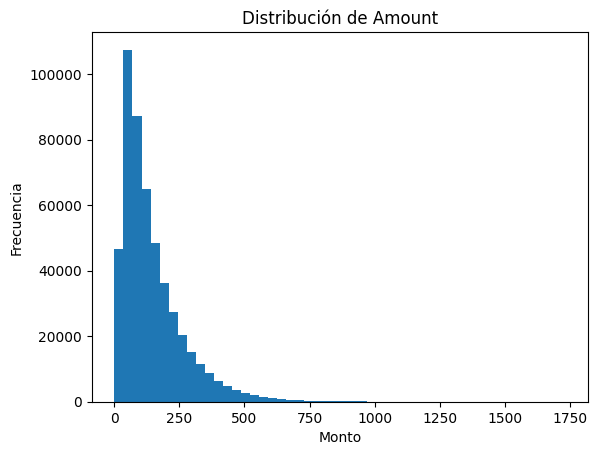

In [ ]:

plt.hist(df['Amount'], bins=50)
plt.title("Distribución de Amount")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.show()

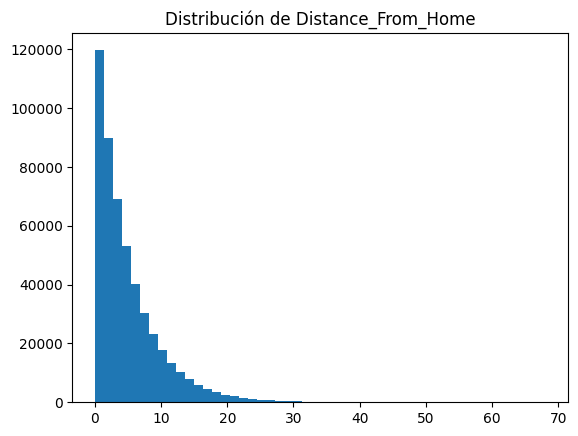

In [ ]:

plt.hist(df['Distance_From_Home'], bins=50)
plt.title("Distribución de Distance_From_Home")
plt.show()

In [ ]:

df['hour'] = df['Transaction_Date'].dt.hour
df['day'] = df['Transaction_Date'].dt.day
df['month'] = df['Transaction_Date'].dt.month

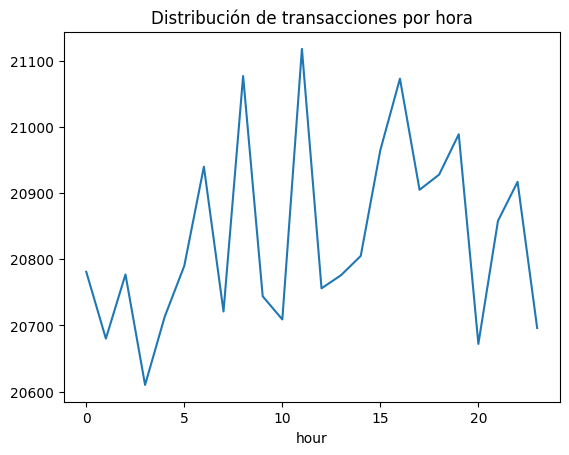

In [ ]:

df['hour'].value_counts().sort_index().plot()

plt.title("Distribución de transacciones por hora")
plt.show()

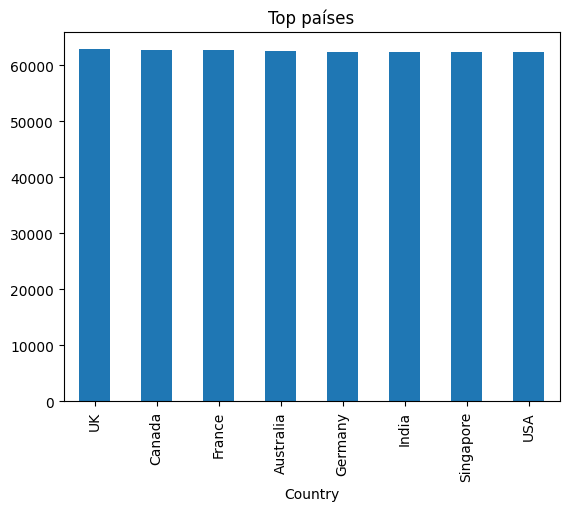

In [ ]:

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top países")
plt.show()

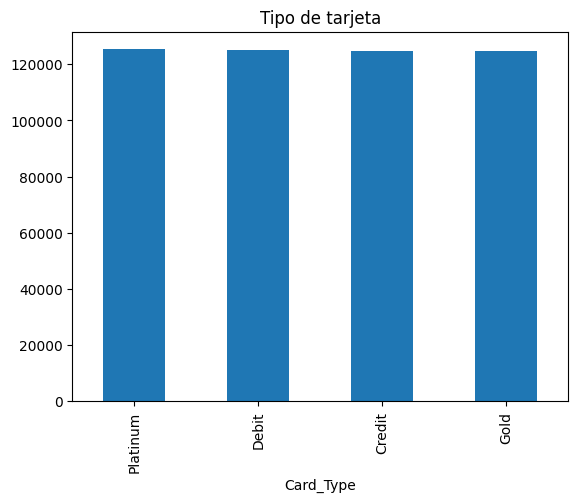

In [ ]:

df['Card_Type'].value_counts().plot(kind='bar')
plt.title("Tipo de tarjeta")
plt.show()

In [ ]:
#Variables binarias
binary_cols = ['Is_International', 'Is_Chip', 'Is_Pin_Used']

for col in binary_cols:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True))


Is_International
Is_International
0    0.850868
1    0.149132
Name: proportion, dtype: float64

Is_Chip
Is_Chip
0    0.699778
1    0.300222
Name: proportion, dtype: float64

Is_Pin_Used
Is_Pin_Used
0    0.8002
1    0.1998
Name: proportion, dtype: float64


In [ ]:
#Outliers en monto
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Amount'] < Q1 - 1.5*IQR) | (df['Amount'] > Q3 + 1.5*IQR)]

print("Outliers en Amount:", outliers.shape[0])

Outliers en Amount: 24215


In [ ]:
#Limpieza preeliminar
df = df.drop(columns=[
    "Transaction_ID",
    "Customer_ID",
    "Merchant_ID"
])

In [ ]:
#Variable objetivo
target_col = "Fraud_Flag"

df[target_col].value_counts(normalize=True)

Fraud_Flag
0    0.985
1    0.015
Name: proportion, dtype: float64

### **Identificación de características clave**

In [ ]:
# Correlación con fraude
corr[target_col].sort_values(ascending=False)

Fraud_Flag            1.000000
month                 0.002909
Transaction_ID        0.001119
Is_Pin_Used           0.000350
Is_Chip               0.000192
Amount               -0.000176
Is_International     -0.000531
Merchant_ID          -0.000548
Customer_ID          -0.000614
day                  -0.001417
Hour_of_Day          -0.001848
hour                 -0.001848
Distance_From_Home   -0.002141
Name: Fraud_Flag, dtype: float64

In [ ]:
#Variables categóricas vs fraude
for col in categorical_cols:
    print(f"\n{col}")
    print(df.groupby(col)[target_col].mean().sort_values(ascending=False).head(5))


Merchant_Category
Merchant_Category
Travel             0.015578
Online Services    0.015571
Groceries          0.015520
Entertainment      0.015198
Health             0.015151
Name: Fraud_Flag, dtype: float64

Card_Type
Card_Type
Credit      0.015300
Debit       0.015102
Platinum    0.015049
Gold        0.014549
Name: Fraud_Flag, dtype: float64

Transaction_Type
Transaction_Type
ATM       0.015028
POS       0.015004
Online    0.014968
Name: Fraud_Flag, dtype: float64

Country
Country
Germany      0.015956
UK           0.015575
India        0.015541
Singapore    0.015012
Australia    0.014852
Name: Fraud_Flag, dtype: float64

Device_Type
Device_Type
Terminal    0.015330
Mobile      0.015242
Web         0.014424
Name: Fraud_Flag, dtype: float64


In [ ]:
#Variables binarias vs fraude
for col in binary_cols:
    print(f"\n{col}")
    print(df.groupby(col)[target_col].mean())


Is_International
Is_International
0    0.015027
1    0.014846
Name: Fraud_Flag, dtype: float64

Is_Chip
Is_Chip
0    0.014985
1    0.015036
Name: Fraud_Flag, dtype: float64

Is_Pin_Used
Is_Pin_Used
0    0.014979
1    0.015085
Name: Fraud_Flag, dtype: float64


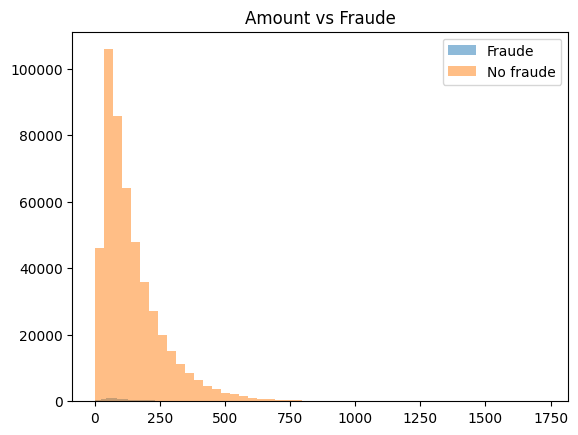

In [ ]:
#Variables continuas vs fraude
fraud = df[df[target_col] == 1]['Amount']
non_fraud = df[df[target_col] == 0]['Amount']

plt.hist(fraud, bins=50, alpha=0.5, label='Fraude')
plt.hist(non_fraud, bins=50, alpha=0.5, label='No fraude')

plt.legend()
plt.title("Amount vs Fraude")
plt.show()